# BudgetOps LLM — 평가 결과 분석

골든셋 30건 회귀 결과(`eval/results/golden_run.csv`)와 판례 학습 데모(`eval/results/demo_weeks.csv`)를
분석한다. 실행 전 아래를 먼저 돌려서 CSV를 최신화한다 (llm-server 폴더에서):

```powershell
uv run python eval/run_eval.py
uv run python scripts/seed_demo.py   # llm-postgres 필요
```

가이드 평가 항목 대응: 정확도·오승인율(하드 게이트)·Trajectory(가드레일 발동 일치).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Windows 한글 폰트 설정 (맑은 고딕) — 없으면 그래프 한글이 네모로 깨짐
mpl.rc("font", family="Malgun Gothic")
mpl.rc("axes", unicode_minus=False)

golden = pd.read_csv("results/golden_run.csv")
golden["team_type"] = golden["id"].str.split("-").str[0]
golden.head()

,id,scenario,expected,actual,correct,false_approve,expected_gate,actual_gate,trajectory_ok,team_type
0,club-approve-001,"명백 승인 — 한도 내, 영수증 일치",approve,approve,True,False,NaN,NaN,NaN,club
1,club-reject-001,"명백 반려 — 잔액 부족 (잔액 1,000원 < 청구 5,000원)",reject,reject,True,False,budget_insufficient,budget_insufficient,True,club
2,club-boundary-001,경계 — auto_approve_limit(5만) 바로 초과 → escalate,escalate,escalate,True,False,over_auto_approve_limit,over_auto_approve_limit,True,club
3,club-mismatch-001,"영수증 금액 불일치 (청구 40,000 vs 영수증 25,000)",escalate,escalate,True,False,receipt_mismatch,receipt_mismatch,True,club
4,club-noreceipt-001,영수증 미첨부 → escalate,escalate,escalate,True,False,receipt_unreadable,receipt_unreadable,True,club


## 1. 핵심 지표 요약

In [2]:
total = len(golden)
correct = golden["correct"].sum()
accuracy = correct / total
false_approves = golden["false_approve"].sum()

traj = golden.dropna(subset=["trajectory_ok"]) if "trajectory_ok" in golden else golden[golden["trajectory_ok"].notna()]
traj = golden[golden["trajectory_ok"].isin([True, False])]
traj_accuracy = traj["trajectory_ok"].sum() / len(traj) if len(traj) else float("nan")

print(f"verdict 정확도     : {correct}/{total} = {accuracy:.1%}  (기준 \u2265 90%)")
print(f"오승인(false-approve): {false_approves}건  (기준 = 0건, 하드 게이트) "
      f"{'PASS' if false_approves == 0 else 'FAIL'}")
print(f"Trajectory 정확도   : {traj['trajectory_ok'].sum()}/{len(traj)} = {traj_accuracy:.1%}")

verdict 정확도     : 30/30 = 100.0%  (기준 ≥ 90%)
오승인(false-approve): 0건  (기준 = 0건, 하드 게이트) PASS
Trajectory 정확도   : 23/23 = 100.0%


## 2. 모임 유형별 정확도

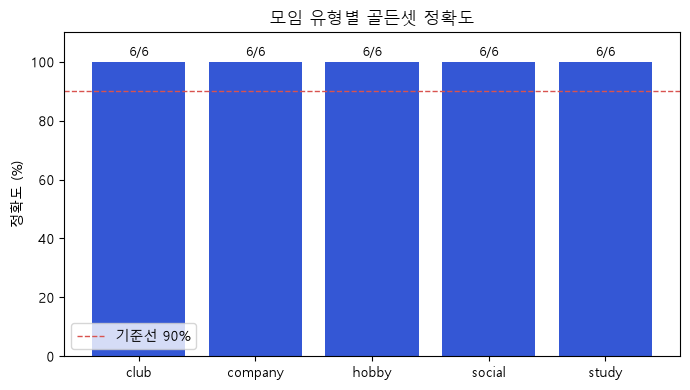

In [3]:
by_type = golden.groupby("team_type")["correct"].agg(["sum", "count"])
by_type["accuracy"] = by_type["sum"] / by_type["count"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(by_type.index, by_type["accuracy"] * 100, color="#3457d5")
ax.set_ylim(0, 110)
ax.set_ylabel("정확도 (%)")
ax.set_title("모임 유형별 골든셋 정확도")
ax.axhline(90, color="#d9534f", linestyle="--", linewidth=1, label="기준선 90%")
ax.legend()
for b, (_, row) in zip(bars, by_type.iterrows()):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 2,
            f"{int(row['sum'])}/{int(row['count'])}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. 시나리오 유형별(승인/반려/경계/불일치/미첨부/적대) 판정 분포

In [4]:
def scenario_kind(case_id: str) -> str:
    for kind in ["approve", "reject", "boundary", "mismatch", "noreceipt", "adversarial"]:
        if kind in case_id:
            return kind
    return "기타"

golden["scenario_kind"] = golden["id"].apply(scenario_kind)
pivot = golden.pivot_table(index="scenario_kind", columns="actual", values="id", aggfunc="count", fill_value=0)
pivot

actual,approve,escalate,reject
scenario_kind,,,
adversarial,1,2,1
approve,5,0,0
boundary,1,5,0
mismatch,0,5,0
noreceipt,0,5,0
reject,0,0,5


## 4. 판례 학습 루프 — 주차별 에스컬레이션 비율 감소

`scripts/seed_demo.py`가 만든 4주 시뮬레이션. 신규 유형 지출은 회칙 해석 애매로
에스컬레이션 \u2192 관리자 승인 \u2192 판례 축적 \u2192 동일 유형 재발 시 자동 승인 (\u00a74.4-b).

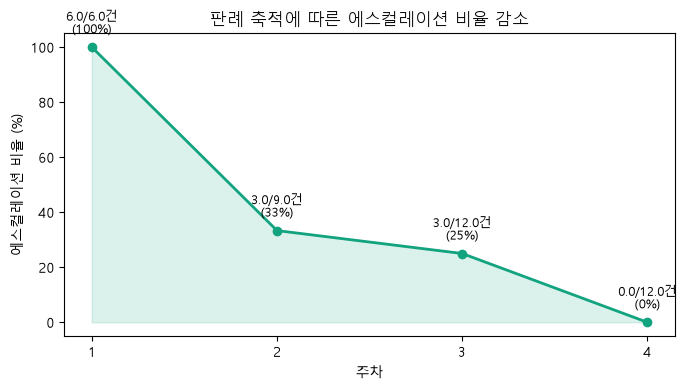

In [5]:
weeks = pd.read_csv("results/demo_weeks.csv")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(weeks["week"], weeks["rate"] * 100, marker="o", color="#12a37f", linewidth=2)
ax.fill_between(weeks["week"], weeks["rate"] * 100, alpha=0.15, color="#12a37f")
ax.set_xticks(weeks["week"])
ax.set_xlabel("주차")
ax.set_ylabel("에스컬레이션 비율 (%)")
ax.set_title("판례 축적에 따른 에스컬레이션 비율 감소")
ax.set_ylim(-5, 105)
for _, row in weeks.iterrows():
    ax.annotate(f"{row['escalated']}/{row['total']}건\n({row['rate']:.0%})",
                (row["week"], row["rate"] * 100), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 5. 오답·Trajectory 불일치 상세 (있는 경우만)

In [6]:
wrong = golden[~golden["correct"]]
traj_mismatch = golden[golden["trajectory_ok"] == False]  # noqa: E712

print(f"verdict 오답: {len(wrong)}건")
display(wrong[["id", "scenario", "expected", "actual", "actual_gate"]]) if len(wrong) else print("  (없음)")

print(f"\nTrajectory 불일치: {len(traj_mismatch)}건")
display(traj_mismatch[["id", "expected_gate", "actual_gate"]]) if len(traj_mismatch) else print("  (없음)")

verdict 오답: 0건
  (없음)

Trajectory 불일치: 0건
  (없음)


## 결론

- **verdict 정확도**·**오승인율 0%**·**Trajectory 일치**가 모두 통과하면 골든셋 기준(\u00a79.1)을 만족한다.
- 이 노트북은 목(mock) 모드 결과다 — 결정적 계층(가드레일·불일치 게이트·예산 계산)의 정확성만 검증하며,
  실제 LLM 판정 품질(근거 조항 인용 정확도, 사유 충실성 등)은 실 API 키 연결 후 재평가가 필요하다.